Testing the state space decoder\
Use the SSdecoder environment which has been cloned from JAL2pipeline but has the replay trajectory classification package installed\
This script is to be run in the JAL2pipeline env and allows us to format the data for testing the SSdecoder

In [1]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip3_18mar, JAL6_flip5_25mar, # (unmatched number of neurons and cluster ids) # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_14may, JAL8_flip4_10may]


session_names = ["JAL4_3rdSept","JAL4_19thSept","JAL4_28aug","JAL4_11thSept",
    "JAL5_8thSept","JAL5_21stSept",
    "JAL6_28mar", "JAL6_flip4_21mar", "JAL6_flip3_18mar", "JAL6_flip5_25mar", 
    "JAL7_sesh8_9apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_sesh9_16apr", "JAL7_23apr",
    "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip3_7may",  "JAL8_14may", "JAL8_flip4_10may"] 

In [2]:
%load_ext autoreload

import os
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import pandas as pd
import matplotlib

matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 15
matplotlib.rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded in PDF

%matplotlib inline

In [ ]:
%matplotlib inline
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.process.process import Process
from JR_test_scripts.escape.functions.escape_utils import load_homing, load_hdir_cells, load_significant_cells
from JR_test_scripts.escape.functions.escape_data_loading_funcs import create_discretized_behave_var
from JR_test_scripts.replay.ReplayUtils import make_escape_bool, make_long_homing_bool, df_to_count_array

homie_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
tuning_data = '_25bins'
cond = 2
bin_width = 0.001 # 1ms bin width

e = 6
exp = experiments_objects[e]
session_name = session_names[e]

In [149]:
"""Load tuning data.
We need to identify significant cells and their tuning preference - build the template"""
sig_cells = load_significant_cells(exp, case = "either_tuned", tuning_data = tuning_data)
hdir = load_hdir_cells([exp], [session_name])
sig_cells[hdir,:] = np.full(3, False)

exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
data = np.load(homie_path + exp_nickname + '_ProperTuning' + tuning_data + '.npz')
sig_escape = data['params_real'][:,:,0] > np.nanpercentile(data['params_shifts'][:,:,:,0], 95, axis = 0)
preferred_tuning = data['params_full'][:,:,1] # preferred %escape for neurons in each condition
tuning_curve = data['fr_full'] # condition x cell x time

2025-05-20 16:44:50.001 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


In [150]:
"""Load the spike, behavior and homing data"""
%autoreload 2

session = Process(exp).load_session()
base_path = os.path.join(session.base_path, session.processed_path)

# matrix
spike_df = pd.read_csv(os.path.join(base_path, "good_spike_data.csv"))
video_df = pl.read_csv(os.path.join(base_path, "full_video_dataframe.csv"))

# extract the condition
y_pos = video_df["mouse_y_position"].to_numpy()
x_pos = video_df["mouse_x_position"].to_numpy()
bar = video_df["barrier_present"].to_numpy()
barflip = video_df["barrier_flipped"].to_numpy()
condition = np.zeros(len(bar))
condition[bar] += 1
condition[barflip] += 1

# load homing
n_frames = int(np.amax(np.unique(video_df['frames'].to_numpy())))
h_on, h_off, homing_bool = load_homing(session, n_frames)

# booleans for homing+escape and explore
# TODO this is a hack into the escapes to remove the 1s of pause before they start running
escape = video_df['EscapePeriod'].to_numpy()
escape_bool = np.full_like(escape, False)
start = np.where(np.diff(escape.astype(int)) == 1)[0]
end = np.where(np.diff(escape.astype(int)) == -1)[0]
for s, e in zip(start, end):
    escape_bool[s+40:e] = True

h_e_bool = (homing_bool | escape_bool) & (video_df['OutofshelterIdx'].to_numpy())

h_start, e_bool = make_escape_bool(h_e_bool, (escape_bool) & (video_df['OutofshelterIdx'].to_numpy()), condition[h_e_bool])
long_homie_bool = make_long_homing_bool(h_start, x_pos[h_e_bool], y_pos[h_e_bool])

# find the times before the homie starts
homie = np.where(np.diff(h_e_bool.astype(int)) > 0)[0] + 1
no_homie = np.where(np.diff(h_e_bool.astype(int)) < 0)[0] + 1

# make bool of long homings only
prebool = np.full(len(h_e_bool), False)
for idx, (s,e) in enumerate(zip(homie, no_homie)):
    if long_homie_bool[idx]:
        prebool[s: e] = True

2025-05-20 16:44:53.076 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2025-05-20 16:46:14.438 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...


In [159]:
save_path = "Z:\Jasmine_Laurence\summary_plots\Replay\SSdecoder"
cond_names = ['shelter_only', 'barrier', 'barrier_flip']
data = np.load(save_path + '\\' + session_name + '_' + cond_names[cond] + '_shelter_period_500ms_windows.npz',)
prebool = data['activity_window_bool']

In [160]:
"""Create matrix of spike counts from spike df"""

spike_frames = spike_df['spike_aligned_to_frame'].to_numpy().astype(int)-1
mask = (condition[spike_frames] == cond) & (prebool[spike_frames])
spike_df_filt = spike_df[mask].copy()

# Create a new column for the time bin index
all_clusters = np.sort(spike_df['spike_clusters'].unique())
spike_df_filt['time_bin'] = (spike_df_filt['aligned_spike_times'] // bin_width).astype(int)
count_matrix = df_to_count_array(spike_df_filt, all_clusters, 'time_bin', fill_time = 10)

count_array = count_matrix.to_numpy() 
count_array = (count_array > 0).astype(int) # still have more than one spike in some cases...
spikes = count_array[sig_cells[:,cond],:]
isort = np.argsort(preferred_tuning[sig_cells[:,cond],cond])

# create a time vector in seconds 
time = np.arange(0, spikes.shape[1]/(1/bin_width), bin_width)

# pull out the frames at which each time bin occurs
time_bin_to_frame = (
    spike_df_filt.groupby('time_bin')['spike_aligned_to_frame']
    .first()  # or .unique() if you expect multiple, or .median() for the middle value
    .reindex(count_matrix.columns)
    .to_numpy()
)

sampling_rate = 30000  # Hz

# Calculate the start time (in samples) for each time_bin
time_bin_starts_sec = np.array(count_matrix.columns) * bin_width
time_bin_starts_samples = (time_bin_starts_sec * sampling_rate).astype(int)

# For each bin, find the corresponding frame (the last frame whose trigger is <= bin start)
frame_for_bin = np.searchsorted(session.camera_trigger.frame_trigger_onsets_idx, 
                                time_bin_starts_samples, side='right')

# Now, frame_for_bin[i] gives the frame index for count_matrix.columns[i]
# TODO: the alignment is not perfect, 
# there is a difference of 1 frame between time_bin_to_frame and frame_for_bin at bin transition times
# this is likely due to rounding errors in the binning process?!

count_array.shape, spikes.shape, time.shape, np.unique(count_array), len(time_bin_to_frame)

((124, 54016), (68, 54016), (54016,), array([0, 1]), 54016)

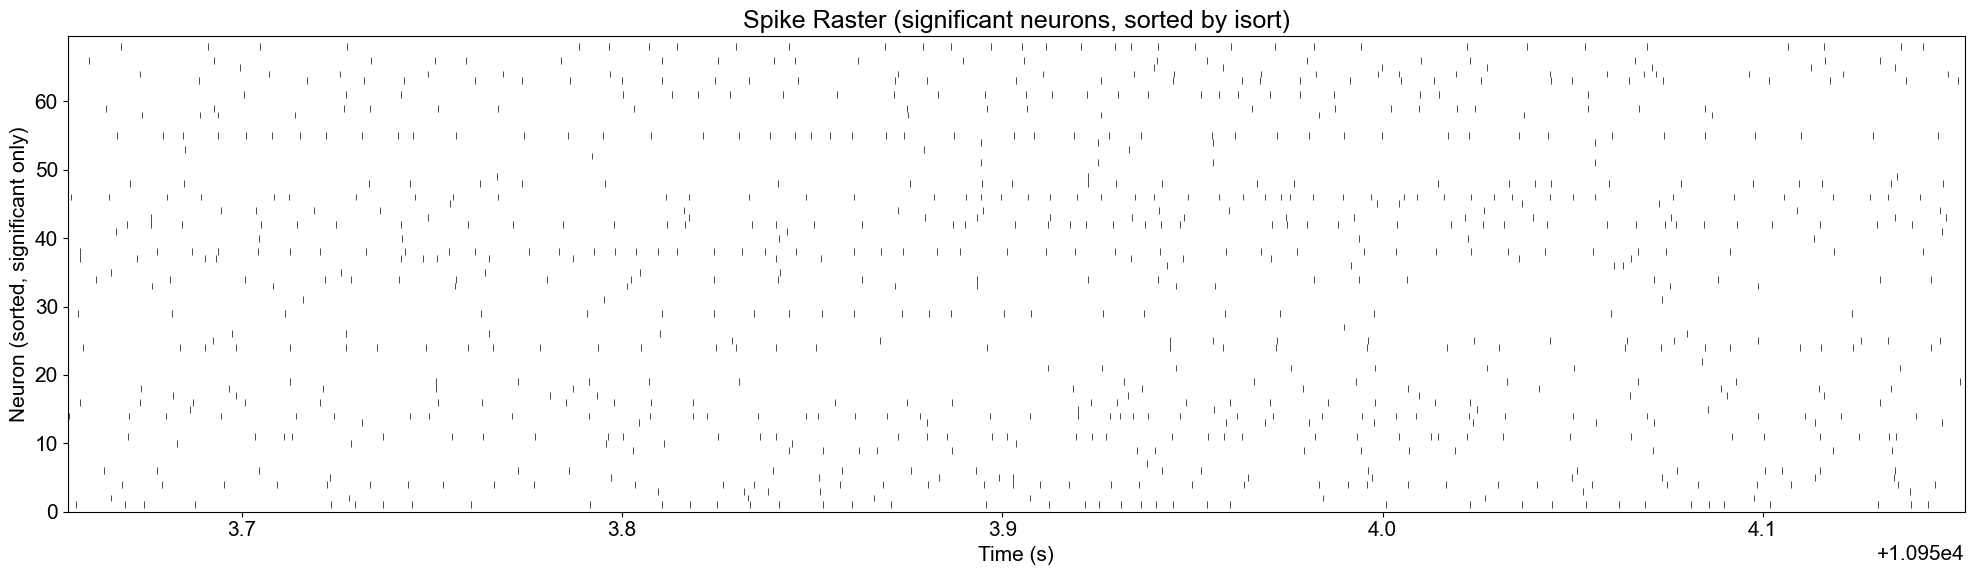

In [165]:
"""Plot rasters of a chosen homing/escape"""
# Assume spike_df_filt is a pandas DataFrame and isort is a numpy array of sorted indices
idx = 6
homie = np.where(np.diff((prebool & (condition == cond)).astype(int)) > 0)[0] + 1
no_homie = np.where(np.diff((prebool & (condition == cond)).astype(int)) < 0)[0] + 1

this_homie = np.full_like(prebool, False)
this_homie[homie[idx]:no_homie[idx]] = True
this_mask = (condition[spike_frames] == cond) & (this_homie[spike_frames])
this_spike_df_filt = spike_df[this_mask].copy()

# Get the unique clusters in the order of isort
sig_cluster_ids = np.sort(np.array(spike_df['spike_clusters'].unique()))[sig_cells[:, cond]]
sorted_sig_clusters = sig_cluster_ids[isort]

plt.figure(figsize=(20, 6))
for row, cluster in enumerate(np.flipud(sorted_sig_clusters)):
    spike_times = this_spike_df_filt.loc[this_spike_df_filt['spike_clusters'] == cluster, 'aligned_spike_times']
    plt.vlines(spike_times, row + 0.5, row + 1.5, color='black', linewidth=0.5)

plt.xlabel('Time (s)')
plt.ylabel('Neuron (sorted, significant only)')
plt.title('Spike Raster (significant neurons, sorted by isort)')
plt.xlim(np.amin(this_spike_df_filt['aligned_spike_times']), np.amax(this_spike_df_filt['aligned_spike_times']))
plt.ylim(0, len(sorted_sig_clusters)+1.5)
plt.tight_layout()
plt.show()

In [153]:
"""Pull out the escape behavioral data and resample to match the neural data"""
Nbins = 25
bins=np.append(np.arange(0,1,1/Nbins), 1+1e-10)

h_on = np.where(np.diff((prebool & (condition == cond).astype(int))) > 0)[0]
h_off = np.where(np.diff((prebool & (condition == cond).astype(int))) < 0)[0]

# initialize variables
esc_var = np.zeros(np.sum(h_off - h_on))
all_frames_to_keep = np.zeros(np.sum(h_off - h_on))
condy = np.zeros(np.sum(h_off - h_on))
start = [0]

for on, of in zip(h_on, h_off):
    # extract variables
    this_y = y_pos[on:of]
    this_x = x_pos[on:of]

    # find actual length of time until mouse is in shelter
    in_shelt_y = this_y > session.shelter_location[0][1]
    in_shelt_x = np.logical_and(
        this_x > session.shelter_location[0][0],
        this_x < session.shelter_location[1][0],
    )
    in_shelt = np.logical_and(in_shelt_x, in_shelt_y)

    frames_to_keep = in_shelt == 0

    # condition vector
    cc = np.zeros((len(this_y)))
    if bar[of] == True:
        cc += 1
    if barflip[of] == True:
        cc += 1

    disc_var = create_discretized_behave_var(session,'escape',this_x,this_y,[],cc,bins=bins)

    # add data from this trial to the escape matrix and behavioral variable
    esc_var[start[-1] : start[-1] + len(disc_var)] = disc_var
    all_frames_to_keep[start[-1] : start[-1] + len(disc_var)] = frames_to_keep
    condy[start[-1] : start[-1] + len(disc_var)] = cc
    start.append(start[-1] + len(disc_var))

# crop data to time before the mouse enters the shelter
condy = condy[all_frames_to_keep == 1]
esc_var = esc_var[all_frames_to_keep == 1]

discretized_escape = esc_var[condy == cond]
# interpolate match the spike data
b = np.zeros(len(prebool))
b[(condition == cond) & (prebool)] = discretized_escape

position = b[frame_for_bin]

ValueError: x and y must have same first dimension, but have shapes (54016,) and (97084,)

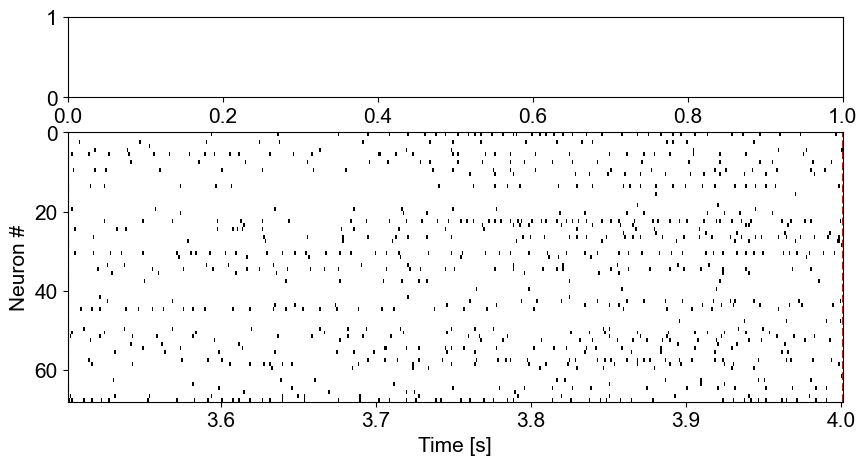

In [166]:
"""We can visualize the spikes as a spike raster"""
# from scipy.stats import zscore
%matplotlib inline
from matplotlib import gridspec
fig = plt.figure(figsize=(10,5))
gs = gridspec.GridSpec(nrows=2, ncols=1, height_ratios = [0.3, 1])

ax = fig.add_subplot(gs[1, 0])
ax.imshow(spikes[isort,:], cmap="gray_r", aspect="auto", interpolation="none",
                    extent=(0, spikes.shape[1]/(1/bin_width), spikes.shape[0], 0))

homie = np.where(np.diff(count_matrix.columns) > 1)[0]

for i in homie:
    # Set limits and plot XY trajectory
    ax.axvline(x=i*bin_width, color='red', linestyle='--')
ax.set_xlabel("Time [s]")
ax.set_ylabel("Neuron #")
ax.set_xlim(homie[idx]*bin_width,homie[idx+1]*bin_width)

"""We can plot position over time"""

ax = fig.add_subplot(gs[0, 0])
ax.plot(time, position, linewidth=2)
ax.set_ylabel(r"% escape")
ax.set_xlim(0, time[-1])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlim(homie[idx]*bin_width,homie[idx+1]*bin_width)

plt.tight_layout()

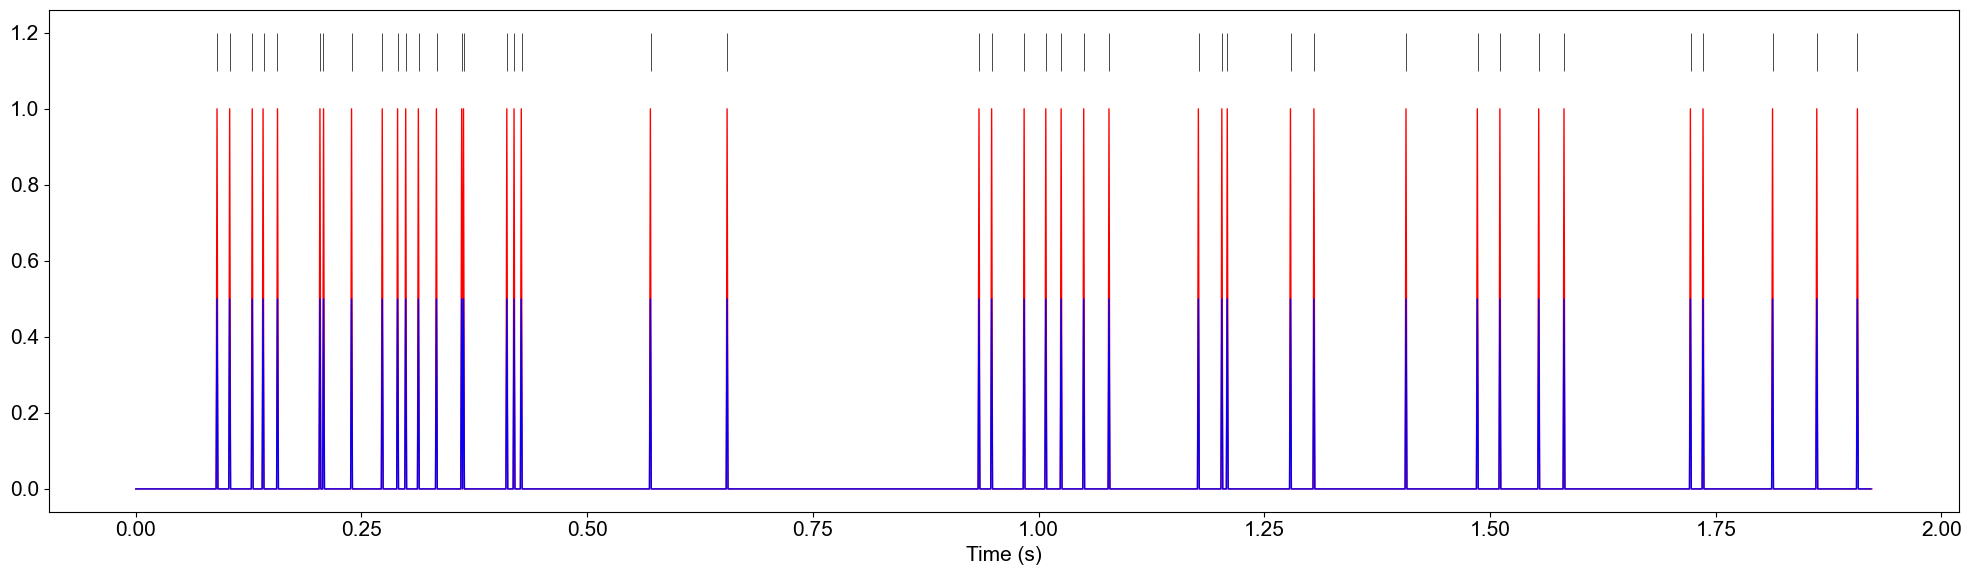

In [119]:
"""Plot the binned spiking of a given neuron with the spike times from the spike df"""
# this is really a sanity check that the binned spiking is correct

idx = 8 # which homing in this condition do we want to look at?
n_i = 12 # which neuron do we want to look at?

homie = np.where(np.diff((prebool & (condition == cond)).astype(int)) > 0)[0] + 1
no_homie = np.where(np.diff((prebool & (condition == cond)).astype(int)) < 0)[0] + 1

this_homie = np.full_like(prebool, False)
this_homie[homie[idx]:no_homie[idx]] = True
this_mask = (condition[spike_frames] == cond) & (this_homie[spike_frames])
this_spike_df_filt = spike_df[this_mask].copy()

# Get the unique clusters in the order of isort
sig_cluster_ids = all_clusters[sig_cells[:, cond]]
sorted_sig_clusters = sig_cluster_ids[isort]

plt.figure(figsize=(20, 6))
# plot the spike times
spike_times = this_spike_df_filt.loc[this_spike_df_filt['spike_clusters'] == sorted_sig_clusters[n_i], 'aligned_spike_times']
spike_times = spike_times - np.amin(this_spike_df_filt['aligned_spike_times'])
plt.vlines(spike_times, 1.1, 1.2, color='black', linewidth=0.5)

# Create a new column for the time bin index
this_spike_df_filt['time_bin'] = (this_spike_df_filt['aligned_spike_times'] // bin_width).astype(int)
this_count_matrix = df_to_count_array(this_spike_df_filt, all_clusters, 'time_bin', fill_time = 10)

this_count_array = this_count_matrix.to_numpy() 
this_count_array = (this_count_array > 0).astype(int) # still have more than one spike in some cases...
this_spikes = this_count_array[sig_cells[:,cond],:]
this_spikes = this_spikes[isort,:]

# create a time vector in seconds 
t = np.arange(0, this_spikes.shape[1]/(1/bin_width), bin_width)
plt.plot(t, this_spikes[n_i,:].T, color='red', linewidth=1)

# plot the binned spiking
this_n = spikes[isort[n_i],:]
s = min(this_spike_df_filt['time_bin'])
e = max(this_spike_df_filt['time_bin'])
t = np.arange(0, (e-s)*bin_width, bin_width)
t = t[:(e-s)]
this_n = this_n[np.where(count_matrix.columns == s)[0][0]:np.where(count_matrix.columns == e)[0][0]]
plt.plot(t, this_n*.5, color='blue', linewidth=1)

plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

In [ ]:
"""Save the vars!"""

save_path = "Z:\Jasmine_Laurence\summary_plots\Replay\SSdecoder"
cond_names = ['shelter_only', 'barrier', 'barrier_flip']
tuning_curves = tuning_curve[cond,sig_cells[:,cond],:]
# save time, position, bin_width and spikes
np.savez(save_path + '\\' + session_name + '_' + cond_names[cond] + '_state_space_decoder_data.npz',
         time=time,
         position=position, 
         bin_width=bin_width,
         spikes=spikes[isort,:],
         tuning_curve=tuning_curves[isort,:],
         h_start = np.where(np.diff(count_matrix.columns) > 1)[0])

Extract the spike matrix for the prehoming period to check for replay

In [155]:
# find the times before the homie starts
homie = np.where(np.diff(h_e_bool.astype(int)) > 0)[0] + 1

# make bool of long homings only
prehomie = np.full(len(h_e_bool), False)
for idx, s in enumerate(homie):
    if long_homie_bool[idx]:
        prehomie[s - (3*40): s] = True

"""Create matrix of spike counts from spike df"""

pre_mask = (condition[spike_frames] == cond) & (prehomie[spike_frames])
pre_df_filt = spike_df[pre_mask].copy()

# Create a new column for the time bin index
all_clusters = np.sort(spike_df['spike_clusters'].unique())
pre_df_filt['time_bin'] = (pre_df_filt['aligned_spike_times'] // bin_width).astype(int)
pre_matrix = df_to_count_array(pre_df_filt, all_clusters, 'time_bin', fill_time = 10)

pre_array = pre_matrix.to_numpy() 
pre_array = (pre_array > 0).astype(int) # still have more than one spike in some cases...
pre_spikes = pre_array[sig_cells[:,cond],:]

# create a time vector in seconds 
pre_time = np.arange(0, pre_spikes.shape[1]/(1/bin_width), bin_width)

pre_array.shape, pre_spikes.shape, pre_time.shape, np.unique(pre_array)

np.savez(save_path + '\\' + session_name + '_' + cond_names[cond] + '_state_space_decoder_prehomie_data.npz',
         time=pre_time,
         bin_width=bin_width,
         spikes=pre_spikes[isort,:],
         h_start = np.where(np.diff(pre_matrix.columns) > 1)[0])